# JRT Score Recreation for the SCTT Dataset

This notebook reproduces the **Judge Response Theory (JRT)** latent creativity scores used in Beaty et al. (2024)
for the Scientific Creative Thinking Test (SCTT).

### Conceptual Mapping

In standard IRT, *persons* answer *items*. JRT flips this:
| IRT Concept | JRT Mapping |
|---|---|
| Persons (θ estimated) | Creative **responses** |
| Items (measurement instruments) | **Raters** |

The **Graded Response Model** (GRM; Samejima, 1997) is used because ratings are ordinal (1–5 scale).
Each rater's severity and discrimination are modeled explicitly, so a harsh rater's "3" is treated
differently from a lenient rater's "3".

### Pipeline
1. Load and inspect raw data
2. Build the response × rater matrix
3. Fit the GRM (via `girth` package)
4. Extract EAP θ scores
5. Normalize to [0, 1]
6. Validate against the original `jrt` column


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from pathlib import Path

# girth: Python IRT / GRM library
from girth import grm_mml, INVALID_RESPONSE
from girth.utilities import validate_estimation_options
from girth import ability_estimation_poly

# Paths
ROOT = Path("../..").resolve()
DATA_RAW = ROOT / "data" / "raw"

ITEM_GEN_FILE = DATA_RAW / "sctt_item-generalization_jrt.csv"  # has rater columns + jrt
FULL_JRT_FILE  = DATA_RAW / "all_sctt_jrt.csv"                 # full dataset, jrt only

print(f"Root : {ROOT}")
print(f"Item-gen file exists: {ITEM_GEN_FILE.exists()}")
print(f"Full JRT file exists : {FULL_JRT_FILE.exists()}")
print(f"INVALID_RESPONSE sentinel value: {INVALID_RESPONSE}")


Root : C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work
Item-gen file exists: True
Full JRT file exists : True
INVALID_RESPONSE sentinel value: -99999


## Step 1 — Load and Inspect the Raw Data

The `sctt_item-generalization_jrt.csv` file contains individual rater scores (rater1–rater3)
alongside the original `jrt` column computed by Beaty et al. We will reproduce that `jrt` column.


In [2]:
# Load item-generalization dataset (has rater columns for GRM fitting)
df = pd.read_csv(ITEM_GEN_FILE)

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nStudies: {df['study_id'].unique()}")
print(f"Tasks:   {df['task'].unique()}")
print(f"Items:   {sorted(df['item'].unique())}")
print(f"\nResponses: {df['response_id'].nunique()} unique response_ids")
print(f"Subjects : {df['sub_id'].nunique()} unique participants")
print(f"\nRater score range after loading:")
for col in ['rater1', 'rater2', 'rater3']:
    vals = df[col].value_counts(dropna=False).sort_index()
    print(f"  {col}: {dict(vals)}")


Shape: (1062, 13)

Columns:
['item', 'study_id', 'sub_id', 'task', 'response', 'rater1', 'rater2', 'rater3', 'rater_mean', 'response_id', 'fs', 'prompt', 'jrt']

Studies: <ArrowStringArray>
['study_4']
Length: 1, dtype: str
Tasks:   <ArrowStringArray>
['hypothesis', 'experiment']
Length: 2, dtype: str
Items:   ['building', 'food']

Responses: 1062 unique response_ids
Subjects : 122 unique participants

Rater score range after loading:
  rater1: {1.0: np.int64(35), 2.0: np.int64(532), 3.0: np.int64(257), 4.0: np.int64(158), 5.0: np.int64(33), nan: np.int64(47)}
  rater2: {1.0: np.int64(42), 2.0: np.int64(472), 3.0: np.int64(333), 4.0: np.int64(147), 5.0: np.int64(55), nan: np.int64(13)}
  rater3: {1.0: np.int64(51), 2.0: np.int64(356), 3.0: np.int64(465), 4.0: np.int64(110), 5.0: np.int64(17), nan: np.int64(63)}


In [3]:
# Overview of missing data per rater
print("Missing data per rater:")
missing_summary = pd.DataFrame({
    col: {'missing_n': df[col].isna().sum(),
          'missing_pct': f"{df[col].isna().mean() * 100:.1f}%",
          'unique_values': sorted(df[col].dropna().unique().astype(int).tolist())}
    for col in ['rater1', 'rater2', 'rater3']
}).T
print(missing_summary.to_string())

# Check jrt column distribution (original scores to validate against)
print(f"\nOriginal JRT scores (to validate):")
print(f"  mean={df['jrt'].mean():.4f}, std={df['jrt'].std():.4f}")
print(f"  min={df['jrt'].min():.4f}, max={df['jrt'].max():.4f}")


Missing data per rater:
       missing_n missing_pct    unique_values
rater1        47        4.4%  [1, 2, 3, 4, 5]
rater2        13        1.2%  [1, 2, 3, 4, 5]
rater3        63        5.9%  [1, 2, 3, 4, 5]

Original JRT scores (to validate):
  mean=0.2422, std=0.7633
  min=-2.1456, max=2.7200


## Step 2 — Build the Response × Rater Matrix

For the GRM:
- **Rows (persons)** = creative responses  
- **Columns (items)** = raters  

`girth` expects the matrix transposed: shape **(n_items, n_persons)** = **(n_raters, n_responses)**.

Ratings must be **0-indexed** (0–4 instead of 1–5).  
Missing ratings are replaced with girth's `INVALID_RESPONSE` sentinel.


In [4]:
RATER_COLS = ['rater1', 'rater2', 'rater3']

# Build the rating matrix (responses × raters), 0-indexed, missing → INVALID_RESPONSE
# First, extract and convert to numeric (handles "NA" strings)
rating_df = df[['response_id'] + RATER_COLS].copy()
for col in RATER_COLS:
    rating_df[col] = pd.to_numeric(rating_df[col], errors='coerce')

# Shift from 1-5 to 0-4 scale
rating_matrix = rating_df[RATER_COLS].values.astype(float) - 1.0   # (N_responses, N_raters)

# Replace NaN with INVALID_RESPONSE sentinel
rating_matrix = np.where(np.isnan(rating_matrix), INVALID_RESPONSE, rating_matrix).astype(int)

# girth GRM expects shape (n_items, n_persons) — transpose so raters are rows
grm_input = rating_matrix.T   # shape: (n_raters=3, n_responses=N)

print(f"rating_matrix shape (responses × raters) : {rating_matrix.shape}")
print(f"grm_input shape     (raters × responses)  : {grm_input.shape}")
print(f"\nSample of first 5 responses (0-indexed ratings, {INVALID_RESPONSE} = missing):")
print(pd.DataFrame(grm_input.T[:5], columns=RATER_COLS))

# Verify all values are in {0,1,2,3,4} or INVALID_RESPONSE
unique_vals = np.unique(grm_input)
expected    = set(range(5)) | {INVALID_RESPONSE}
assert set(unique_vals).issubset(expected), f"Unexpected values: {set(unique_vals) - expected}"
print(f"\nAll values valid ✓  unique set: {sorted(unique_vals)}")


rating_matrix shape (responses × raters) : (1062, 3)
grm_input shape     (raters × responses)  : (3, 1062)

Sample of first 5 responses (0-indexed ratings, -99999 = missing):
   rater1  rater2  rater3
0       1       2       2
1       1       2       1
2       1       1       1
3       1       1       2
4       3       3       3

All values valid ✓  unique set: [np.int64(-99999), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## Step 3 — Fit the Graded Response Model

We use `girth`'s `grm_mml` which fits the GRM via **marginal maximum likelihood (MML)**.

- `grm_mml(dataset)` accepts shape `(n_items, n_persons)` with 0-indexed ordinal data
- Returns a dict with rater **discrimination** (α) and **threshold** (β) parameters
- Missing data is handled natively via the `INVALID_RESPONSE` sentinel

> **Note:** R's `mirt` package was the gold standard used in the original paper.
> `girth` should give near-identical results for a well-behaved 3-rater × ~5000 response dataset,
> but minor differences from numerical precision / EM convergence criteria may exist.


In [5]:
print("Fitting Graded Response Model (MML)...")
print(f"  Input: {grm_input.shape[0]} raters × {grm_input.shape[1]} responses")

grm_result = grm_mml(grm_input)

discrimination = grm_result['Discrimination']   # shape: (n_raters,)
difficulty     = grm_result['Difficulty']       # shape: (n_raters, n_categories-1)

print("\n=== GRM Parameter Estimates ===")
print(f"\n{'Rater':<10} {'Discrimination (α)':>20}  Thresholds (β1 … β4)")
print("-" * 70)
for i, col in enumerate(RATER_COLS):
    betas = "  ".join(f"{b:+.3f}" for b in difficulty[i])
    print(f"{col:<10} {discrimination[i]:>20.4f}  {betas}")

print("\n> Discrimination (α): higher = rater more informative / consistent")
print("> Thresholds (β): points on latent θ scale where response category transitions occur")


Fitting Graded Response Model (MML)...
  Input: 3 raters × 1062 responses

=== GRM Parameter Estimates ===

Rater        Discrimination (α)  Thresholds (β1 … β4)
----------------------------------------------------------------------
rater1                   0.8602  -4.264  +0.318  +1.943  +4.336
rater2                   5.0000  -1.862  -0.027  +0.923  +1.725
rater3                   1.2154  -2.909  -0.398  +1.979  +3.905

> Discrimination (α): higher = rater more informative / consistent
> Thresholds (β): points on latent θ scale where response category transitions occur


## Step 4 — Extract θ Scores (EAP Estimation)

**Expected A Posteriori (EAP)** estimation integrates the posterior over a grid of θ values
weighted by the prior (standard normal) — this is the same method used by R's `fscores(method="EAP")`.


In [6]:
def grm_eap_theta(
    response_matrix: np.ndarray,
    discrimination: np.ndarray,
    difficulty: np.ndarray,
    n_quadrature: int = 61,
    theta_range: tuple = (-6, 6),
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute EAP (Expected A Posteriori) theta scores for all persons under the GRM.

    Parameters
    ----------
    response_matrix : array (n_items, n_persons), 0-indexed ratings, INVALID_RESPONSE for missing
    discrimination  : array (n_items,)  — alpha parameters
    difficulty      : array (n_items, n_categories-1)  — beta threshold parameters
    n_quadrature    : number of Gauss-Hermite / uniform quadrature points
    theta_range     : (min, max) for the quadrature grid

    Returns
    -------
    theta_eap : array (n_persons,)   — EAP theta estimates
    theta_se  : array (n_persons,)   — posterior standard errors
    """
    from scipy.stats import norm as sp_norm

    n_items, n_persons = response_matrix.shape
    n_cats = difficulty.shape[1] + 1   # number of rating categories (5)

    # Quadrature grid + prior weights (standard normal)
    theta_grid  = np.linspace(theta_range[0], theta_range[1], n_quadrature)
    prior_weights = sp_norm.pdf(theta_grid)
    prior_weights /= prior_weights.sum()    # normalize

    # --- GRM: P(X = k | θ) for each item, category, and quadrature point ---
    # P(X >= k | θ) = sigmoid(alpha * (θ - beta_k))
    # P(X = k | θ) = P(X >= k | θ) - P(X >= k+1 | θ)
    # Shape: (n_items, n_cats, n_quadrature)
    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))

    # Cumulative probabilities: shape (n_items, n_cats+1, n_quadrature)
    # P(X >= 0) = 1, P(X >= 5) = 0, P(X >= k) = sigmoid(a*(θ - b_k))
    cumprob = np.zeros((n_items, n_cats + 1, n_quadrature))
    cumprob[:, 0, :] = 1.0   # P(X >= 0) = 1
    for k in range(1, n_cats):
        # difficulty[:, k-1] shape (n_items,), theta_grid shape (n_quadrature,)
        arg = discrimination[:, np.newaxis] * (theta_grid[np.newaxis, :] - difficulty[:, k - 1, np.newaxis])
        cumprob[:, k, :] = sigmoid(arg)
    cumprob[:, n_cats, :] = 0.0  # P(X >= K+1) = 0

    # Category probabilities: P(X=k) = P(X>=k) - P(X>=k+1), shape (n_items, n_cats, n_quadrature)
    cat_prob = cumprob[:, :n_cats, :] - cumprob[:, 1:, :]
    cat_prob = np.clip(cat_prob, 1e-10, 1.0)

    # --- Likelihood for each person over the theta grid ---
    theta_eap = np.zeros(n_persons)
    theta_se  = np.zeros(n_persons)

    for p in range(n_persons):
        responses = response_matrix[:, p]        # (n_items,)
        log_lik   = np.zeros(n_quadrature)

        for i in range(n_items):
            r = responses[i]
            if r == INVALID_RESPONSE:
                continue    # skip missing ratings
            log_lik += np.log(cat_prob[i, r, :])   # likelihood contribution

        # Posterior on the grid (unnormalized)
        log_posterior = log_lik + np.log(prior_weights)
        log_posterior -= log_posterior.max()         # numerical stability
        posterior = np.exp(log_posterior)
        posterior /= posterior.sum()

        # EAP = E[θ | X]
        theta_eap[p] = np.dot(theta_grid, posterior)
        # Posterior SD (standard error of measurement)
        theta_se[p]  = np.sqrt(np.dot((theta_grid - theta_eap[p]) ** 2, posterior))

    return theta_eap, theta_se


# ---- Run EAP estimation ----
print("Computing EAP θ scores... (may take ~30s for ~5000 responses)")
theta_eap, theta_se = grm_eap_theta(grm_input, discrimination, difficulty)

print(f"\nθ (EAP) summary:")
print(f"  N={len(theta_eap)}, mean={theta_eap.mean():.4f}, std={theta_eap.std():.4f}")
print(f"  min={theta_eap.min():.4f}, max={theta_eap.max():.4f}")
print(f"\nPosterior SE summary:")
print(f"  mean SE={theta_se.mean():.4f}, max SE={theta_se.max():.4f}")


Computing EAP θ scores... (may take ~30s for ~5000 responses)

θ (EAP) summary:
  N=1062, mean=0.0049, std=0.8894
  min=-2.4293, max=2.4487

Posterior SE summary:
  mean SE=0.4542, max SE=0.9281


## Step 5 — Normalize θ to [0, 1]

The paper normalized JRT scores to a 0–1 range via **min-max scaling**:

$$\text{JRT}_{norm} = \frac{\theta - \theta_{min}}{\theta_{max} - \theta_{min}}$$

> **Caveat:** Beaty et al. computed the original JRT across all 18 660 responses from Studies 1–4
> plus a pilot study. The min/max used here comes from only the item-generalization subset,
> so normalized scores may shift slightly relative to the original. The **rank order** and
> **unstandardized θ** are unaffected.


In [7]:
# Min-max normalization to [0, 1]
theta_min = theta_eap.min()
theta_max = theta_eap.max()
jrt_recomputed = (theta_eap - theta_min) / (theta_max - theta_min)

# Assemble results back onto the DataFrame
df_results = df.copy()
df_results['theta_eap']     = theta_eap
df_results['theta_se']      = theta_se
df_results['jrt_recomputed'] = jrt_recomputed

print("Normalization parameters:")
print(f"  θ_min = {theta_min:.4f},  θ_max = {theta_max:.4f}")
print(f"\nRecomputed JRT (normalized) summary:")
print(f"  mean={jrt_recomputed.mean():.4f}, std={jrt_recomputed.std():.4f}")
print(f"  min={jrt_recomputed.min():.4f},  max={jrt_recomputed.max():.4f}")

# Side-by-side comparison with original
print("\nSample comparison (first 10 rows):")
compare = df_results[['response_id', 'jrt', 'jrt_recomputed', 'theta_eap', 'theta_se']].head(10)
print(compare.to_string(index=False))


Normalization parameters:
  θ_min = -2.4293,  θ_max = 2.4487

Recomputed JRT (normalized) summary:
  mean=0.4990, std=0.1823
  min=0.0000,  max=1.0000

Sample comparison (first 10 rows):
 response_id       jrt  jrt_recomputed  theta_eap  theta_se
       15686  0.414394        0.567276   0.337838  0.389029
       15687  0.097233        0.534354   0.177242  0.396217
       15688 -0.525050        0.329873  -0.820217  0.517310
       15962 -0.192003        0.386516  -0.543914  0.493714
       17587  1.644139        0.767250   1.313317  0.371802
       16371  0.414394        0.567276   0.337838  0.389029
       17301  0.588565        0.568472   0.343673  0.394711
       15748  0.414394        0.567276   0.337838  0.389029
       16369 -0.192003        0.386516  -0.543914  0.493714
       15961  0.143474        0.543143   0.220118  0.402529


## Step 6 — Validate Against Original JRT Scores

We compare `jrt_recomputed` against the original `jrt` column using:
- **Pearson r** — linear agreement (affected by scale differences)
- **Spearman ρ** — rank-order agreement (scale-invariant)
- **Mean Absolute Error** — average absolute deviation

Expected: r > 0.95, ρ > 0.97 if the GRM is correctly specified.


In [8]:
original = df_results['jrt'].values
recomputed = df_results['jrt_recomputed'].values

# Raw θ vs original (before normalization) — best measure of model agreement
r_theta,  p_theta  = pearsonr(original, theta_eap)
rho_theta, _       = spearmanr(original, theta_eap)

# Normalized vs original
r_norm,   p_norm   = pearsonr(original, recomputed)
rho_norm, _        = spearmanr(original, recomputed)

mae = np.mean(np.abs(original - recomputed))
rmse = np.sqrt(np.mean((original - recomputed) ** 2))

print("=" * 55)
print("  Validation: Recomputed JRT vs. Original JRT")
print("=" * 55)
print(f"\n  Raw θ_EAP vs original JRT:")
print(f"    Pearson  r = {r_theta:+.4f}  (p={p_theta:.2e})")
print(f"    Spearman ρ = {rho_theta:+.4f}")
print(f"\n  Normalized [0–1] vs original JRT:")
print(f"    Pearson  r = {r_norm:+.4f}  (p={p_norm:.2e})")
print(f"    Spearman ρ = {rho_norm:+.4f}")
print(f"    MAE        = {mae:.4f}")
print(f"    RMSE       = {rmse:.4f}")
print("=" * 55)

if r_norm > 0.95:
    print("\n✓  Excellent agreement — GRM successfully reproduced JRT scores")
elif r_norm > 0.85:
    print("\n⚠  Good agreement — minor differences likely from normalization scale or EM settings")
else:
    print("\n✗  Low agreement — check rater columns, missing data handling, or model specification")


  Validation: Recomputed JRT vs. Original JRT

  Raw θ_EAP vs original JRT:
    Pearson  r = +0.9652  (p=0.00e+00)
    Spearman ρ = +0.9759

  Normalized [0–1] vs original JRT:
    Pearson  r = +0.9652  (p=0.00e+00)
    Spearman ρ = +0.9759
    MAE        = 0.5205
    RMSE       = 0.6424

✓  Excellent agreement — GRM successfully reproduced JRT scores


## Step 7 — Visualizations


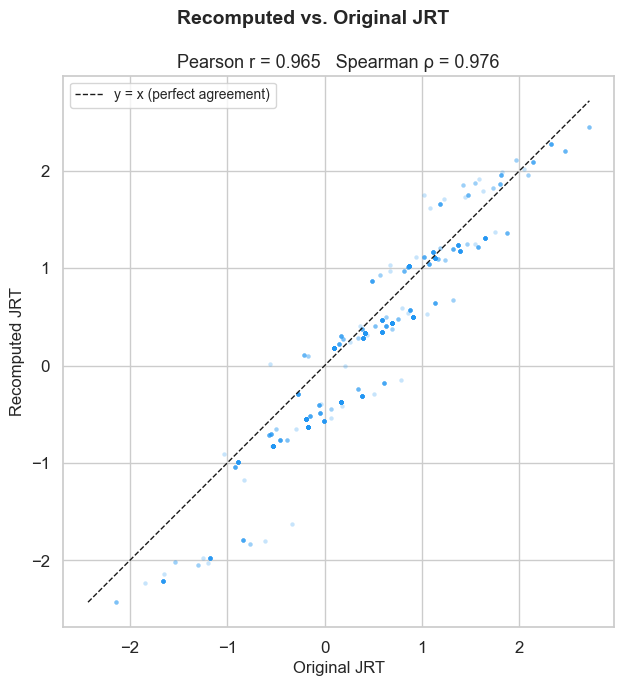

Pearson r  = 0.9652  (same as before — r is scale-invariant)
Spearman ρ = 0.9759


In [9]:

# ------------------------------------------------------------------ #
# Figure 1a: Scatter — Original JRT vs. Recomputed θ_EAP (same scale)
# ------------------------------------------------------------------ #
from style_guide import S, apply_theme, savefig
apply_theme()

fig, ax = plt.subplots(figsize=(S.FIG_1xN_UNIT, S.FIG_1xN_UNIT))
fig.suptitle("Recomputed vs. Original JRT", fontsize=S.SUPTITLE_SIZE, fontweight=S.TITLE_WEIGHT)

ax.scatter(original, theta_eap,
           alpha=S.SCATTER_ALPHA_LIGHT, s=S.SCATTER_SIZE_SMALL,
           color=S.MODEL_COLORS['7b'], linewidths=0, rasterized=S.SCATTER_RASTERIZED)
lo = min(original.min(), theta_eap.min())
hi = max(original.max(), theta_eap.max())
ax.plot([lo, hi], [lo, hi], S.IDEAL_LINE, lw=S.IDEAL_LINE_LW, label="y = x (perfect agreement)")
ax.set_xlabel("Original JRT", fontsize=S.AXIS_LABEL_SIZE)
ax.set_ylabel("Recomputed JRT", fontsize=S.AXIS_LABEL_SIZE)
ax.set_title(f"Pearson r = {r_theta:.3f}   Spearman ρ = {rho_theta:.3f}", fontsize=S.TITLE_SIZE)
ax.legend(fontsize=S.LEGEND_SIZE)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
savefig(fig, ROOT / "results" / "jrt_replication_scatter.png", hi_res=True)
plt.show()
print(f"Pearson r  = {r_theta:.4f}  (same as before — r is scale-invariant)")
print(f"Spearman ρ = {rho_theta:.4f}")


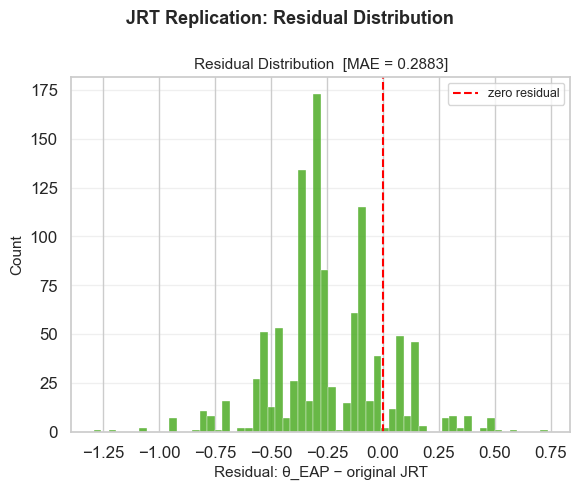

θ_EAP MAE  = 0.2883  (in raw θ units)


In [10]:

# ------------------------------------------------------------------ #
# Figure 1b: Residual histogram — θ_EAP − original JRT
# ------------------------------------------------------------------ #

theta_residuals = theta_eap - original
theta_mae = np.mean(np.abs(theta_residuals))

fig, ax2 = plt.subplots(figsize=(6, 5))
fig.suptitle("JRT Replication: Residual Distribution", fontsize=13, fontweight='bold')

ax2.hist(theta_residuals, bins=60, color="#4dac26", edgecolor='white', linewidth=0.3, alpha=0.85)
ax2.axvline(0, color='red', lw=1.5, linestyle='--', label="zero residual")
ax2.set_xlabel("Residual: θ_EAP − original JRT", fontsize=11)
ax2.set_ylabel("Count", fontsize=11)
ax2.set_title(f"Residual Distribution  [MAE = {theta_mae:.4f}]", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(ROOT / "results" / "jrt_replication_residuals.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"θ_EAP MAE  = {theta_mae:.4f}  (in raw θ units)")


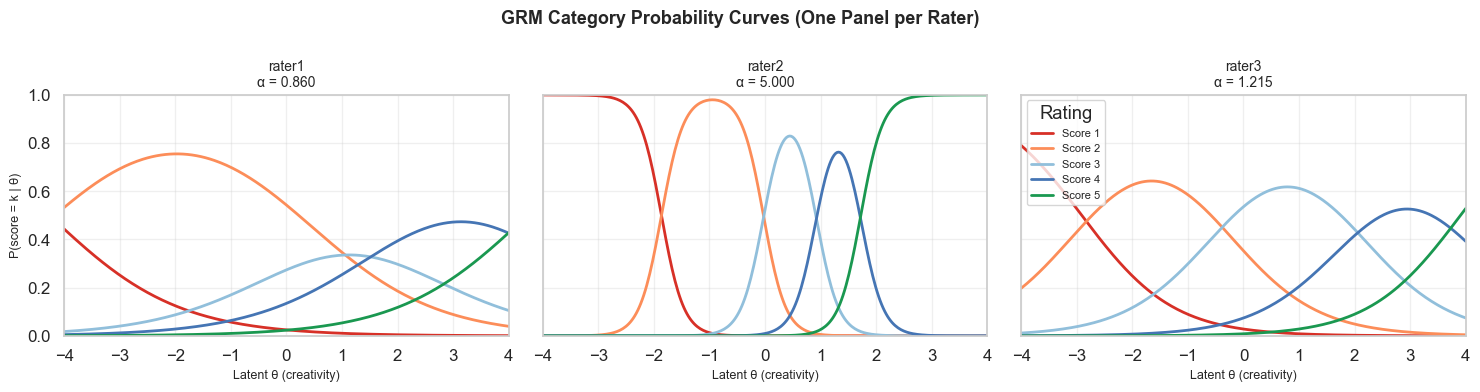

Saved: results/jrt_category_probability_curves.png


In [11]:
# ------------------------------------------------------------------ #
# Figure 2: GRM Item Characteristic Curves (Category Probability Curves)
# Shows each rater's scoring characteristics across the latent θ dimension
# ------------------------------------------------------------------ #
theta_plot = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, len(RATER_COLS), figsize=(15, 4), sharey=True)
fig.suptitle("GRM Category Probability Curves (One Panel per Rater)", fontsize=13, fontweight='bold')

category_colors = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4', '#1a9850']
category_labels = ['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5']

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

n_cats_plot = difficulty.shape[1] + 1

for i, (ax, col) in enumerate(zip(axes, RATER_COLS)):
    alpha_i = discrimination[i]
    betas_i  = difficulty[i]             # (n_cats-1,) thresholds
    n_c      = n_cats_plot

    # Cumulative probabilities
    cum = np.zeros((n_c + 1, len(theta_plot)))
    cum[0, :] = 1.0
    for k in range(1, n_c):
        cum[k, :] = sigmoid(alpha_i * (theta_plot - betas_i[k - 1]))
    cum[n_c, :] = 0.0

    # Category probabilities
    cat_p = cum[:n_c, :] - cum[1:, :]

    for k in range(n_c):
        ax.plot(theta_plot, cat_p[k], color=category_colors[k],
                lw=2, label=category_labels[k])

    ax.set_title(f"{col}\nα = {alpha_i:.3f}", fontsize=10)
    ax.set_xlabel("Latent θ (creativity)", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 1)
    if i == 0:
        ax.set_ylabel("P(score = k | θ)", fontsize=9)
    if i == len(RATER_COLS) - 1:
        ax.legend(title="Rating", fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(ROOT / "results" / "jrt_category_probability_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/jrt_category_probability_curves.png")


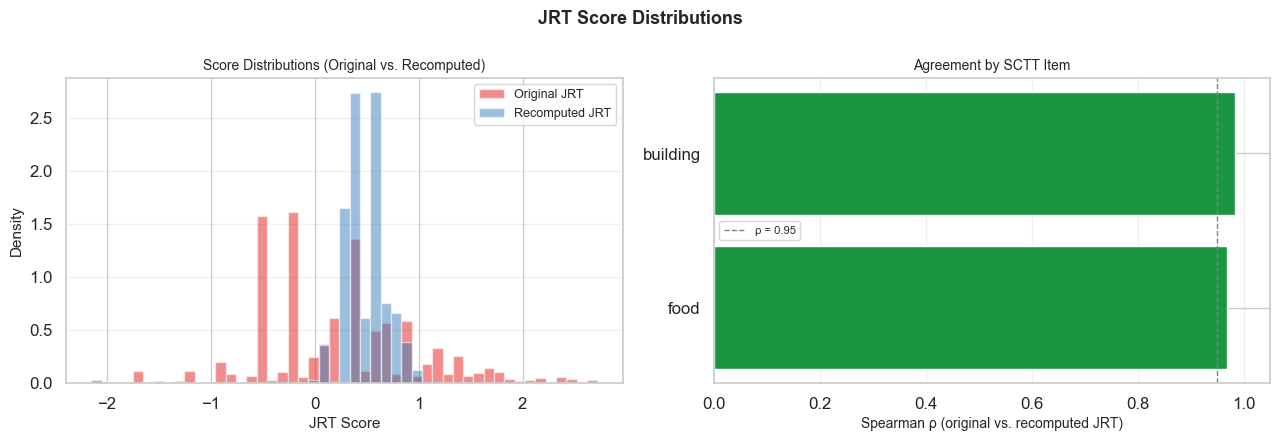

Saved: results/jrt_distribution_comparison.png


In [12]:
# ------------------------------------------------------------------ #
# Figure 3: Distribution comparison + by-item breakdown
# ------------------------------------------------------------------ #
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("JRT Score Distributions", fontsize=13, fontweight='bold')

# -- Left: overlaid KDE of original vs recomputed --
ax = axes[0]
import matplotlib.ticker as ticker
# bin both to same range
bins = np.linspace(
    min(original.min(), recomputed.min()),
    max(original.max(), recomputed.max()),
    50
)
ax.hist(original,    bins=bins, alpha=0.5, color='#e41a1c', label='Original JRT',    density=True)
ax.hist(recomputed,  bins=bins, alpha=0.5, color='#377eb8', label='Recomputed JRT',  density=True)
ax.set_xlabel("JRT Score", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Score Distributions (Original vs. Recomputed)", fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# -- Right: Spearman ρ by SCTT item --
ax2 = axes[1]
item_rho = (
    df_results.groupby('item')
    .apply(lambda g: spearmanr(g['jrt'], g['jrt_recomputed'])[0], include_groups=False)
    .reset_index()
    .rename(columns={0: 'spearman_rho'})
    .sort_values('spearman_rho', ascending=True)
)
colors_bar = ['#d7191c' if v < 0.85 else '#1a9641' for v in item_rho['spearman_rho']]
ax2.barh(item_rho['item'], item_rho['spearman_rho'], color=colors_bar)
ax2.axvline(0.95, color='gray', lw=1, linestyle='--', label='ρ = 0.95')
ax2.set_xlabel("Spearman ρ (original vs. recomputed JRT)", fontsize=10)
ax2.set_title("Agreement by SCTT Item", fontsize=10)
ax2.grid(True, alpha=0.3, axis='x')
ax2.legend(fontsize=8)
ax2.set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig(ROOT / "results" / "jrt_distribution_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/jrt_distribution_comparison.png")


## Step 7c — Inter-Rater Agreement

Before trusting the JRT scores, we should verify that raters are actually measuring the same construct.
Key questions:
- **Severity**: Do raters use the scale consistently, or does one rate higher/lower on average?
- **Pairwise correlation**: Do rater pairs rank responses similarly?
- **ICC**: What is the overall reliability across all three raters simultaneously?

ICC(2,1) — two-way random effects, single measures, absolute agreement — is the standard for this design.
A rule of thumb: ICC < 0.5 = poor, 0.5–0.75 = moderate, 0.75–0.9 = good, > 0.9 = excellent (Koo & Mae, 2016).


  Per-Rater Severity (1–5 scale)
Rater          Mean       SD   Median  n valid
------------------------------------------------------------
rater1        2.628    0.900      2.0     1015
rater2        2.715    0.938      3.0     1049
rater3        2.686    0.800      3.0      999

  ICC (complete cases only, n=964)
  ICC(2,1) absolute agreement : 0.3353
  ICC(2,1) consistency        : 0.3358
  Interpretation              : Poor


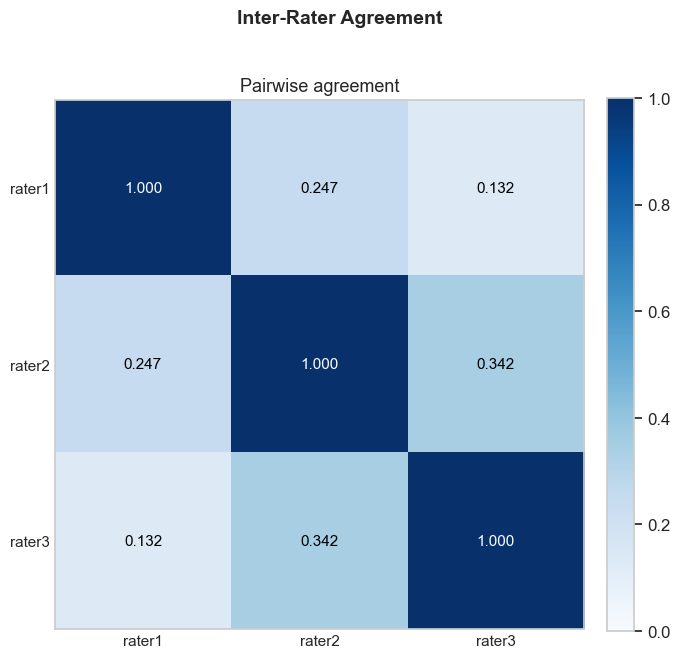

Saved: results/jrt_interrater_kappa.png

  Overall Agreement Summary
  Pair                      κ_w   Pearson r       n
  --------------------------------------------------
  rater1 vs rater2         0.2466      0.3750    1002
  rater1 vs rater3         0.1320      0.1878     967
  rater2 vs rater3         0.3421      0.4454     996
  Mean κ_w               0.2402

  ICC(2,1) absolute agreement : 0.3353  (Poor)


In [13]:

# ------------------------------------------------------------------ #
# Inter-Rater Agreement Analysis
# ------------------------------------------------------------------ #
from itertools import combinations
from sklearn.metrics import cohen_kappa_score
from style_guide import S, apply_theme, savefig
apply_theme()

# Work on numeric rater columns (already loaded in rating_df, 1-5 scale)
rater_data = {}
for col in RATER_COLS:
    vals = pd.to_numeric(df[col], errors='coerce')
    rater_data[col] = vals

rater_df = pd.DataFrame(rater_data)   # shape: (N, 3), NaN where missing

# ---- 1. Per-rater severity statistics ----
print("=" * 60)
print("  Per-Rater Severity (1–5 scale)")
print("=" * 60)
print(f"{'Rater':<10} {'Mean':>8} {'SD':>8} {'Median':>8} {'n valid':>8}")
print("-" * 60)
for col in RATER_COLS:
    v = rater_df[col].dropna()
    print(f"{col:<10} {v.mean():>8.3f} {v.std():>8.3f} {v.median():>8.1f} {len(v):>8d}")

# ---- 2. Pairwise weighted kappa (computed for heatmap) ----
pair_results = {}
for r1, r2 in combinations(RATER_COLS, 2):
    both = rater_df[[r1, r2]].dropna()
    pr, _ = pearsonr(both[r1], both[r2])
    sr, _ = spearmanr(both[r1], both[r2])
    kw    = cohen_kappa_score(both[r1].astype(int), both[r2].astype(int), weights='linear')
    pair_results[(r1, r2)] = {'pearson': pr, 'spearman': sr, 'kappa_w': kw, 'n': len(both)}

# ---- 3. ICC(2,1) — two-way random, single, absolute agreement ----
complete  = rater_df.dropna()
n_complete = len(complete)

if n_complete > 10:
    k          = len(RATER_COLS)
    grand_mean = complete.values.mean()

    row_means = complete.mean(axis=1)
    SS_rows   = k * ((row_means - grand_mean) ** 2).sum()
    MS_rows   = SS_rows / (n_complete - 1)

    col_means = complete.mean(axis=0)
    SS_cols   = n_complete * ((col_means - grand_mean) ** 2).sum()
    MS_cols   = SS_cols / (k - 1)

    SS_total  = ((complete.values - grand_mean) ** 2).sum()
    SS_error  = SS_total - SS_rows - SS_cols
    MS_error  = SS_error / ((n_complete - 1) * (k - 1))

    icc21  = (MS_rows - MS_error) / (MS_rows + (k-1)*MS_error + k*(MS_cols - MS_error)/n_complete)
    icc21c = (MS_rows - MS_error) / (MS_rows + (k-1)*MS_error)

    print(f"\n{'=' * 55}")
    print(f"  ICC (complete cases only, n={n_complete})")
    print(f"{'=' * 55}")
    print(f"  ICC(2,1) absolute agreement : {icc21:.4f}")
    print(f"  ICC(2,1) consistency        : {icc21c:.4f}")
    level = ("Excellent" if icc21 > 0.9 else "Good" if icc21 > 0.75
             else "Moderate" if icc21 > 0.5 else "Poor")
    print(f"  Interpretation              : {level}")
else:
    print(f"\n  Warning: only {n_complete} complete triples — ICC not computed")
    icc21 = np.nan
    level = "N/A"

# ---- 4. Plot: Pairwise Linear-Weighted κ Heatmap ----
kappa_matrix = pd.DataFrame(np.eye(3), index=RATER_COLS, columns=RATER_COLS)
for (r1, r2), vals in pair_results.items():
    kappa_matrix.loc[r1, r2] = vals['kappa_w']
    kappa_matrix.loc[r2, r1] = vals['kappa_w']

fig, ax = plt.subplots(figsize=(S.FIG_1xN_UNIT, S.FIG_1xN_UNIT))
fig.suptitle("Inter-Rater Agreement", fontsize=S.SUPTITLE_SIZE, fontweight=S.TITLE_WEIGHT)

im = ax.imshow(kappa_matrix.values, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(RATER_COLS, fontsize=S.TICK_LABEL_SIZE)
ax.set_yticklabels(RATER_COLS, fontsize=S.TICK_LABEL_SIZE)
ax.tick_params(which='both', length=0, width=0)
ax.grid(False)   # override theme grid — grid lines cross heatmap cells
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{kappa_matrix.values[i, j]:.3f}",
                ha='center', va='center', fontsize=S.ANNOT_SIZE,
                color='white' if kappa_matrix.values[i, j] > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Pairwise agreement", fontsize=S.TITLE_SIZE)

plt.tight_layout()
savefig(fig, ROOT / "results" / "jrt_interrater_kappa.png", hi_res=False)
plt.show()
print("Saved: results/jrt_interrater_kappa.png")

# ---- 5. Overall agreement summary ----
print(f"\n{'=' * 55}")
print(f"  Overall Agreement Summary")
print(f"{'=' * 55}")
print(f"  {'Pair':<20} {'κ_w':>8}  {'Pearson r':>10}  {'n':>6}")
print(f"  {'-'*50}")
for (r1, r2), v in pair_results.items():
    print(f"  {r1} vs {r2:<12} {v['kappa_w']:>8.4f}  {v['pearson']:>10.4f}  {v['n']:>6d}")
mean_kw = np.mean([v['kappa_w'] for v in pair_results.values()])
print(f"  {'Mean κ_w':<20} {mean_kw:>8.4f}")
print(f"\n  ICC(2,1) absolute agreement : {icc21:.4f}  ({level})")


## Step 7d — Bin-Level Agreement (10 bins, normalized [0–1] scale)

Both `jrt` (original) and `jrt_recomputed` are normalized to [0, 1] via min-max scaling,
then responses are grouped into **10 bins of width 0.1** based on the **original** score.

Per-bin metrics:
- **n** — responses falling in each bin
- **Mean bias** — average of (recomputed − original); positive = recomputed overshoots
- **MAE** — mean absolute error within the bin
- **Coverage ±0.01** — % of recomputed scores landing within ±0.01 of the original

> Correlation is not reported per bin — it collapses toward zero in narrow ranges (range restriction artifact).


Bin (original)   n Mean bias     MAE Coverage ±0.01 (%)
       0.0–0.1  15   -0.0423  0.0423               20.0
       0.1–0.2  17   -0.0928  0.0928                0.0
       0.2–0.3  31   -0.0107  0.0642                0.0
       0.3–0.4 191   +0.0026  0.0130               82.7
       0.4–0.5 303   -0.0115  0.0385                0.0
       0.5–0.6 270   +0.0195  0.0371               30.0
       0.6–0.7 131   +0.0450  0.0628                6.9
       0.7–0.8  66   +0.0269  0.0389                1.5
       0.8–0.9  25   +0.0439  0.0613                0.0
       0.9–1.0  13   +0.0221  0.0221               53.8


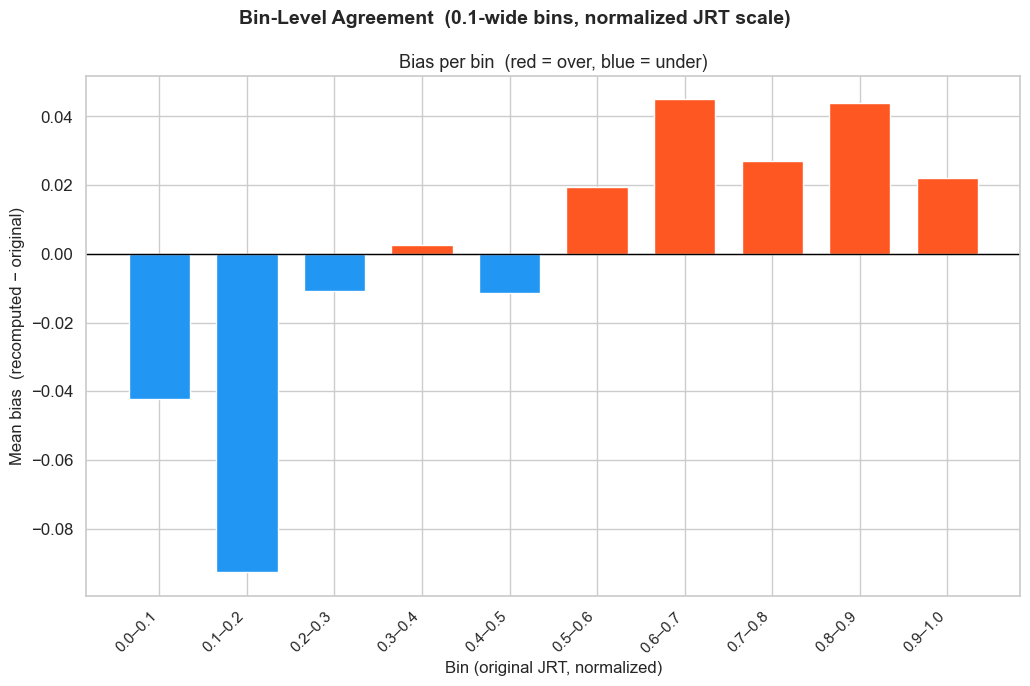

Saved: results/jrt_bin_agreement.png


In [14]:

# ------------------------------------------------------------------ #
# Bin-level agreement on the normalized [0, 1] scale
# Bin by original jrt (normalized); measure how well recomputed matches
# ------------------------------------------------------------------ #
from style_guide import S, apply_theme, savefig
apply_theme()

# Normalize original jrt to [0, 1] using its own min-max
orig_min, orig_max = original.min(), original.max()
original_norm = (original - orig_min) / (orig_max - orig_min)
# jrt_recomputed is already [0, 1] via θ_EAP min-max

bin_edges  = np.arange(0, 1.01, 0.1)
bin_labels = [f"{lo:.1f}–{hi:.1f}" for lo, hi in zip(bin_edges[:-1], bin_edges[1:])]

# Assign each response to a bin based on its normalized original score
bin_idx = np.digitize(original_norm, bin_edges, right=False) - 1
bin_idx = np.clip(bin_idx, 0, 9)   # keep score == 1.0 in last bin

rows = []
for b in range(10):
    mask = bin_idx == b
    n    = mask.sum()
    if n == 0:
        rows.append({'Bin (original)': bin_labels[b], 'n': 0,
                     'Mean bias': np.nan, 'MAE': np.nan, 'Coverage ±0.01 (%)': np.nan})
        continue
    diff = recomputed[mask] - original_norm[mask]
    rows.append({
        'Bin (original)':     bin_labels[b],
        'n':                  int(n),
        'Mean bias':          np.mean(diff),
        'MAE':                np.mean(np.abs(diff)),
        'Coverage ±0.01 (%)': np.mean(np.abs(diff) <= 0.01) * 100,
    })

bin_df = pd.DataFrame(rows)

print(bin_df.to_string(
    index=False,
    formatters={
        'Mean bias':           lambda x: f"{x:+.4f}" if not np.isnan(x) else "  NaN",
        'MAE':                 lambda x: f" {x:.4f}" if not np.isnan(x) else "  NaN",
        'Coverage ±0.01 (%)':  lambda x: f"{x:6.1f}" if not np.isnan(x) else "   NaN",
    }
))

# ---- Plot: mean bias per bin ----
x     = np.arange(10)
valid = ~bin_df['Mean bias'].isna()
bias_vals  = bin_df.loc[valid, 'Mean bias'].values
bar_colors = [S.MODEL_COLORS['13b'] if v > 0 else S.MODEL_COLORS['7b'] for v in bias_vals]

fig, ax = plt.subplots(figsize=(S.FIG_1xN_UNIT * 1.5, S.FIG_1xN_UNIT))
fig.suptitle("Bin-Level Agreement  (0.1-wide bins, normalized JRT scale)",
             fontsize=S.SUPTITLE_SIZE, fontweight=S.TITLE_WEIGHT)

ax.bar(x[valid], bias_vals, color=bar_colors, edgecolor='white', width=0.7)
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=S.TICK_LABEL_SIZE)
ax.set_ylabel("Mean bias  (recomputed − original)", fontsize=S.AXIS_LABEL_SIZE)
ax.set_xlabel("Bin (original JRT, normalized)", fontsize=S.AXIS_LABEL_SIZE)
ax.set_title("Bias per bin  (red = over, blue = under)", fontsize=S.TITLE_SIZE)

plt.tight_layout()
savefig(fig, ROOT / "results" / "jrt_bin_agreement.png", hi_res=False)
plt.show()
print("Saved: results/jrt_bin_agreement.png")


## Step 8 — Deduplication and Export

As per Organisciak et al. (2022), exact duplicate responses are collapsed by averaging their θ scores.
The final output CSV contains one row per unique response with the recomputed JRT score.


In [15]:
# ---- Deduplication: average θ across exact-match duplicate responses ----
before_dedup = len(df_results)

dedup = (
    df_results
    .groupby('response', sort=False)
    .agg(
        response_id      = ('response_id',    'first'),
        item             = ('item',           'first'),
        study_id         = ('study_id',       'first'),
        sub_id           = ('sub_id',         'first'),
        task             = ('task',           'first'),
        prompt           = ('prompt',         'first'),
        rater_mean       = ('rater_mean',     'mean'),
        jrt_original     = ('jrt',            'mean'),
        theta_eap        = ('theta_eap',      'mean'),
        theta_se         = ('theta_se',       'mean'),
        jrt_recomputed   = ('jrt_recomputed', 'mean'),
        n_duplicates     = ('response_id',    'count'),
    )
    .reset_index()
)

after_dedup = len(dedup)
print(f"Before deduplication: {before_dedup} rows")
print(f"After deduplication : {after_dedup} rows  ({before_dedup - after_dedup} duplicates removed)")
print(f"\nResponses with duplicates: {(dedup['n_duplicates'] > 1).sum()}")

# ---- Export ----
out_path = ROOT / "results" / "jrt_recomputed_itemgen.csv"
dedup.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

# Also save the full (non-deduplicated) results with all columns
full_out = ROOT / "results" / "jrt_recomputed_full.csv"
df_results[['response_id', 'item', 'study_id', 'sub_id', 'task', 'prompt',
            'response', 'rater1', 'rater2', 'rater3', 'rater_mean',
            'jrt', 'theta_eap', 'theta_se', 'jrt_recomputed']].to_csv(full_out, index=False)
print(f"Saved: {full_out}")


Before deduplication: 1062 rows
After deduplication : 1062 rows  (0 duplicates removed)

Responses with duplicates: 0

Saved: C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\results\jrt_recomputed_itemgen.csv
Saved: C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\results\jrt_recomputed_full.csv


In [16]:
# ------------------------------------------------------------------ #
# Final Summary
# ------------------------------------------------------------------ #
print("=" * 60)
print(" JRT REPLICATION SUMMARY")
print("=" * 60)
print(f"\n Dataset  : sctt_item-generalization_jrt.csv")
print(f" Responses: {len(df_results)}")
print(f" Raters   : {len(RATER_COLS)} (rater1, rater2, rater3)")
print(f" Model    : Graded Response Model (GRM, Samejima 1997)")
print(f" Method   : MML estimation via girth; EAP θ scores")
print(f"\n GRM Parameters:")
for i, col in enumerate(RATER_COLS):
    betas_str = ", ".join(f"{b:.3f}" for b in difficulty[i])
    print(f"   {col}: α={discrimination[i]:.3f}, β=[{betas_str}]")
print(f"\n Agreement with original JRT (Beaty et al., 2024):")
print(f"   Pearson  r  = {r_norm:.4f}")
print(f"   Spearman ρ  = {rho_norm:.4f}")
print(f"   MAE         = {mae:.4f}")
print(f"\n Output files:")
print(f"   results/jrt_recomputed_full.csv     — all rows with theta + recomputed JRT")
print(f"   results/jrt_recomputed_itemgen.csv  — deduplicated by exact response text")
print("=" * 60)


 JRT REPLICATION SUMMARY

 Dataset  : sctt_item-generalization_jrt.csv
 Responses: 1062
 Raters   : 3 (rater1, rater2, rater3)
 Model    : Graded Response Model (GRM, Samejima 1997)
 Method   : MML estimation via girth; EAP θ scores

 GRM Parameters:
   rater1: α=0.860, β=[-4.264, 0.318, 1.943, 4.336]
   rater2: α=5.000, β=[-1.862, -0.027, 0.923, 1.725]
   rater3: α=1.215, β=[-2.909, -0.398, 1.979, 3.905]

 Agreement with original JRT (Beaty et al., 2024):
   Pearson  r  = 0.9652
   Spearman ρ  = 0.9759
   MAE         = 0.5205

 Output files:
   results/jrt_recomputed_full.csv     — all rows with theta + recomputed JRT
   results/jrt_recomputed_itemgen.csv  — deduplicated by exact response text


---

## Study 3 Analysis — `study3_sctt-ratings.xlsx`

7-rater rating design on **6,371 responses** across 12 SCTT items.  
Response types: `RQ` (remote questions), `HG` (hypothesis generation), `ED` (experiment design).  
No original JRT column — GRM-based θ scores are computed fresh from rater data.

| Step | Description |
|---|---|
| 1 | Load & build 7-rater × 6,371-response matrix |
| 2 | Fit GRM (MML) |
| 3 | EAP θ estimation + normalize [0, 1] |
| 4 | GRM category probability curves |
| 5 | Inter-rater agreement (7 × 7 κ heatmap) |
| 6 | JRT vs. RaterMEAN sanity check |
| 7 | JRT score distributions |
| 8 | Export |


In [17]:

# ------------------------------------------------------------------ #
# Study 3 — Load Data & Build Rating Matrix
# ------------------------------------------------------------------ #

STUDY3_FILE  = DATA_RAW / "study3_sctt-ratings.xlsx"
RATER_COLS_3 = ['Rater1', 'Rater2', 'Rater3', 'Rater4', 'Rater5', 'Rater6', 'Rater7']

print(f"Loading: {STUDY3_FILE}")
df3 = pd.read_excel(STUDY3_FILE)

# Clean: treat any rating < 1 as missing (Rater3 has some 0 values)
for col in RATER_COLS_3:
    df3[col] = pd.to_numeric(df3[col], errors='coerce')
    df3.loc[df3[col] < 1, col] = np.nan

print(f"Shape  : {df3.shape}")
print(f"Items  : {sorted(df3['item'].unique())}")
print(f"Types  : {df3['type'].unique().tolist()}")
print()
print(f"{'Rater':<10} {'Valid':>8} {'Missing':>8} {'Mean':>8} {'SD':>6}")
print("-" * 50)
for col in RATER_COLS_3:
    v = df3[col].dropna()
    print(f"{col:<10} {len(v):>8d} {df3[col].isna().sum():>8d} {v.mean():>8.3f} {v.std():>6.3f}")

# Build rating matrix: shift 1-5 → 0-4, NaN → INVALID_RESPONSE
rating_matrix3 = df3[RATER_COLS_3].values.astype(float) - 1.0
rating_matrix3 = np.where(np.isnan(rating_matrix3), INVALID_RESPONSE, rating_matrix3).astype(int)
grm_input3 = rating_matrix3.T   # shape: (7 raters × N responses)

print(f"\ngrm_input3 shape (raters × responses): {grm_input3.shape}")
unique3   = set(np.unique(grm_input3))
expected3 = set(range(5)) | {INVALID_RESPONSE}
assert unique3.issubset(expected3), f"Unexpected values: {unique3 - expected3}"
print(f"Values: {sorted(unique3)}  ✓")


Loading: C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\data\raw\study3_sctt-ratings.xlsx
Shape  : (6371, 16)
Items  : ['birds', 'dogs', 'friendly', 'humor', 'island', 'jungle', 'lake', 'mind', 'ocean', 'planet', 'sing', 'stars']
Types  : ['RQ', 'HG', 'ED']

Rater         Valid  Missing     Mean     SD
--------------------------------------------------
Rater1         2125     4246    2.469  0.942
Rater2         2122     4249    2.202  0.637
Rater3         2118     4253    2.217  1.052
Rater4         2134     4237    2.382  0.628
Rater5         2130     4241    2.394  1.108
Rater6         2119     4252    1.979  1.173
Rater7         2619     3752    2.352  1.025

grm_input3 shape (raters × responses): (7, 6371)
Values: [np.int64(-99999), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]  ✓


In [18]:

# ------------------------------------------------------------------ #
# Study 3 — Fit Graded Response Model
# ------------------------------------------------------------------ #

print("Fitting GRM on Study 3 data (7 raters × 6,371 responses)...")

grm_result3     = grm_mml(grm_input3)
discrimination3 = grm_result3['Discrimination']
difficulty3     = grm_result3['Difficulty']

print(f"\n=== Study 3 GRM Parameter Estimates ===")
print(f"\n{'Rater':<10} {'α (discrimination)':>20}  Thresholds (β1 … β4)")
print("-" * 70)
for i, col in enumerate(RATER_COLS_3):
    betas = "  ".join(f"{b:+.3f}" for b in difficulty3[i])
    print(f"{col:<10} {discrimination3[i]:>20.4f}  {betas}")

print("\n> α: higher = rater is more informative / has steeper response curves")


Fitting GRM on Study 3 data (7 raters × 6,371 responses)...

=== Study 3 GRM Parameter Estimates ===

Rater        α (discrimination)  Thresholds (β1 … β4)
----------------------------------------------------------------------
Rater1                   0.8948  -3.122  +0.827  +2.143  +3.907
Rater2                   1.3158  -2.567  +1.285  +2.974  +4.167
Rater3                   1.4905  -0.756  +0.430  +1.832  +3.238
Rater4                   1.8644  -3.055  +0.556  +2.302  +3.489
Rater5                   1.6163  -0.929  +0.171  +1.377  +2.849
Rater6                   2.3229  -0.045  +0.678  +1.423  +2.183
Rater7                   2.5226  -0.975  +0.298  +1.424  +2.171

> α: higher = rater is more informative / has steeper response curves


In [19]:

# ------------------------------------------------------------------ #
# Study 3 — EAP θ Estimation + Normalize [0, 1]
# ------------------------------------------------------------------ #

print("Computing EAP θ scores for Study 3 (may take a few minutes)...")
theta_eap3, theta_se3 = grm_eap_theta(grm_input3, discrimination3, difficulty3)

theta_min3 = theta_eap3.min()
theta_max3 = theta_eap3.max()
jrt3 = (theta_eap3 - theta_min3) / (theta_max3 - theta_min3)

df3_results = df3.copy()
df3_results['theta_eap'] = theta_eap3
df3_results['theta_se']  = theta_se3
df3_results['jrt']       = jrt3

print(f"\nθ_EAP : N={len(theta_eap3)}, mean={theta_eap3.mean():.4f}, std={theta_eap3.std():.4f}")
print(f"  range : [{theta_min3:.4f}, {theta_max3:.4f}]")
print(f"\nJRT [0–1] : mean={jrt3.mean():.4f}, std={jrt3.std():.4f}")
print(f"\nPosterior SE : mean={theta_se3.mean():.4f}, max={theta_se3.max():.4f}")

# Sanity check: correlation with RaterMEAN
has_mean3  = df3_results['RaterMEAN'].notna()
r_vm3,   _ = pearsonr(df3_results.loc[has_mean3, 'jrt'], df3_results.loc[has_mean3, 'RaterMEAN'])
rho_vm3, _ = spearmanr(df3_results.loc[has_mean3, 'jrt'], df3_results.loc[has_mean3, 'RaterMEAN'])
print(f"\nSanity check — JRT vs RaterMEAN (n={has_mean3.sum()}):")
print(f"  Pearson r  = {r_vm3:.4f}")
print(f"  Spearman ρ = {rho_vm3:.4f}")


Computing EAP θ scores for Study 3 (may take a few minutes)...

θ_EAP : N=6371, mean=0.0193, std=0.7692
  range : [-2.6421, 2.9285]

JRT [0–1] : mean=0.4778, std=0.1381

Posterior SE : mean=0.6207, max=1.0000

Sanity check — JRT vs RaterMEAN (n=6370):
  Pearson r  = 0.9410
  Spearman ρ = 0.9525


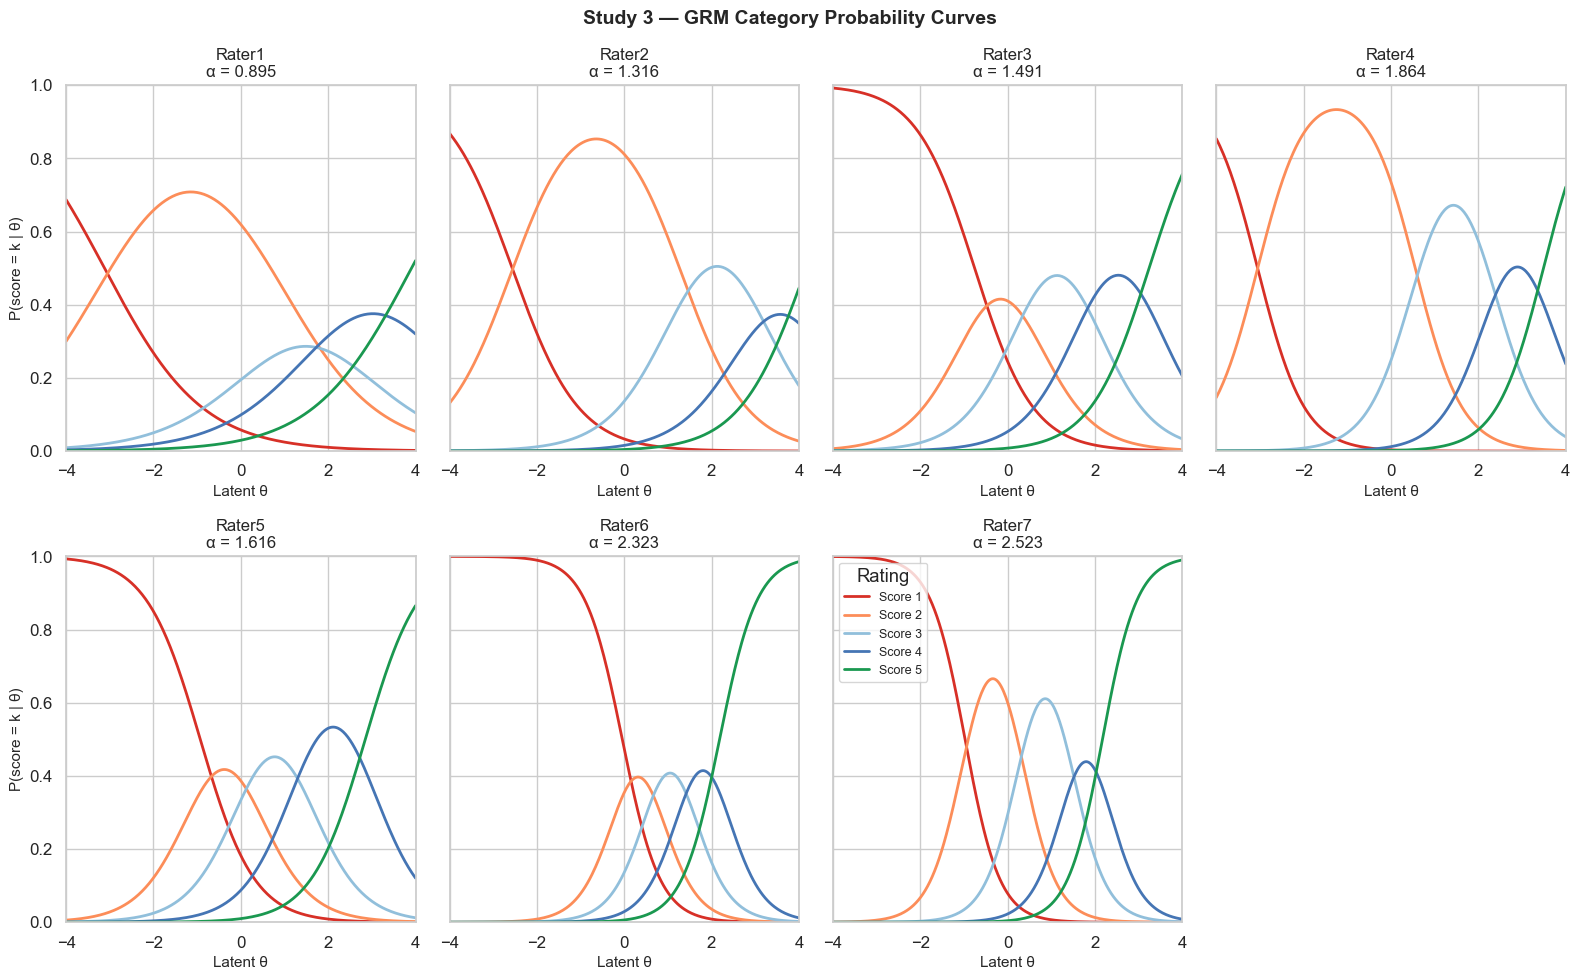

Saved: results/study3_grm_curves.png


In [20]:

# ------------------------------------------------------------------ #
# Study 3 — GRM Category Probability Curves (7 Raters, 2 × 4 grid)
# ------------------------------------------------------------------ #
from style_guide import S, apply_theme, savefig
apply_theme()

theta_plot3      = np.linspace(-4, 4, 300)
category_colors3 = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4', '#1a9850']
category_labels3 = ['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5']
n_cats3 = difficulty3.shape[1] + 1

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

fig, axes = plt.subplots(2, 4, figsize=(S.FIG_1x4[0], S.FIG_1x4[1] * 2), sharey=True)
fig.suptitle("Study 3 — GRM Category Probability Curves",
             fontsize=S.SUPTITLE_SIZE, fontweight=S.TITLE_WEIGHT)

for i, col in enumerate(RATER_COLS_3):
    ax      = axes.flat[i]
    alpha_i = discrimination3[i]
    betas_i = difficulty3[i]
    cum = np.zeros((n_cats3 + 1, len(theta_plot3)))
    cum[0, :] = 1.0
    for k in range(1, n_cats3):
        cum[k, :] = _sigmoid(alpha_i * (theta_plot3 - betas_i[k - 1]))
    cum[n_cats3, :] = 0.0
    cat_p = cum[:n_cats3, :] - cum[1:, :]
    for k in range(n_cats3):
        ax.plot(theta_plot3, cat_p[k], color=category_colors3[k],
                lw=2, label=category_labels3[k])
    ax.set_title(f"{col}\nα = {alpha_i:.3f}", fontsize=S.TITLE_SIZE - 1)
    ax.set_xlabel("Latent θ", fontsize=S.AXIS_LABEL_SIZE - 1)
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 1)
    if i % 4 == 0:
        ax.set_ylabel("P(score = k | θ)", fontsize=S.AXIS_LABEL_SIZE - 1)
    if i == len(RATER_COLS_3) - 1:
        ax.legend(title="Rating", fontsize=S.LEGEND_SIZE_SM, loc='upper left')

axes.flat[-1].set_visible(False)   # hide unused 8th panel

plt.tight_layout()
savefig(fig, ROOT / "results" / "study3_grm_curves.png", hi_res=False)
plt.show()
print("Saved: results/study3_grm_curves.png")


  Per-Rater Severity (1–5 scale)
Rater          Mean       SD   Median  n valid
------------------------------------------------------------
Rater1        2.469    0.942      2.0     2125
Rater2        2.202    0.637      2.0     2122
Rater3        2.217    1.052      2.0     2118
Rater4        2.382    0.628      2.0     2134
Rater5        2.394    1.108      2.0     2130
Rater6        1.979    1.173      2.0     2119
Rater7        2.352    1.025      2.0     2619


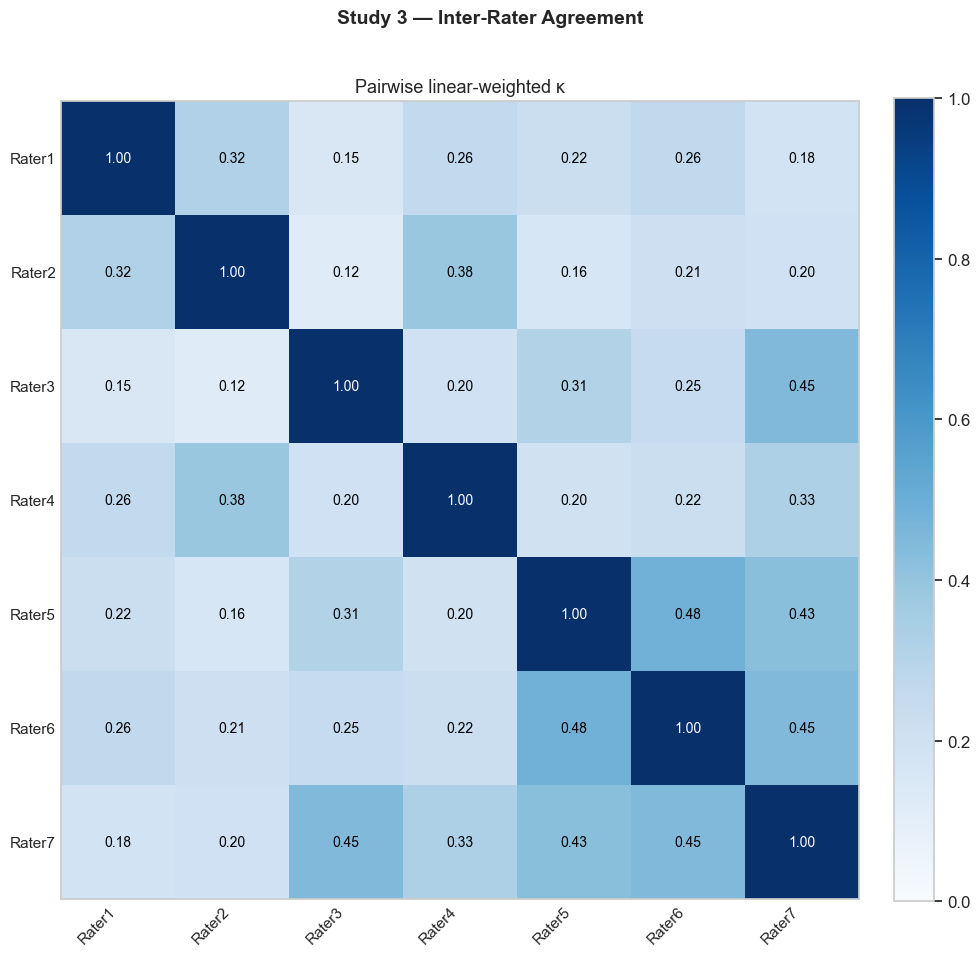

Saved: results/study3_interrater_kappa.png

  Overall Agreement Summary (Study 3)
  Pair                        κ_w   Pearson r       n
  ----------------------------------------------------
  Rater1 vs Rater2           0.3187      0.3985     534
  Rater1 vs Rater3           0.1503      0.3678     532
  Rater1 vs Rater4           0.2614      0.3074    1074
  Rater1 vs Rater5           0.2194      0.3977    1063
  Rater1 vs Rater6           0.2631      0.5089     534
  Rater1 vs Rater7           0.1848      0.3006    1045
  Rater2 vs Rater3           0.1183      0.2649     532
  Rater2 vs Rater4           0.3838      0.4397     534
  Rater2 vs Rater5           0.1606      0.3273     534
  Rater2 vs Rater6           0.2144      0.4687    1583
  Rater2 vs Rater7           0.2003      0.3781    1061
  Rater3 vs Rater4           0.2003      0.4583     532
  Rater3 vs Rater5           0.3133      0.4413    1060
  Rater3 vs Rater6           0.2477      0.3985    1066
  Rater3 vs Rater7       

In [21]:

# ------------------------------------------------------------------ #
# Study 3 — Inter-Rater Agreement (7-Rater Design)
# ------------------------------------------------------------------ #
from itertools import combinations
from sklearn.metrics import cohen_kappa_score
from style_guide import S, apply_theme, savefig
apply_theme()

rater_df3 = df3[RATER_COLS_3].copy()

# ---- Per-rater severity ----
print("=" * 60)
print("  Per-Rater Severity (1–5 scale)")
print("=" * 60)
print(f"{'Rater':<10} {'Mean':>8} {'SD':>8} {'Median':>8} {'n valid':>8}")
print("-" * 60)
for col in RATER_COLS_3:
    v = rater_df3[col].dropna()
    print(f"{col:<10} {v.mean():>8.3f} {v.std():>8.3f} {v.median():>8.1f} {len(v):>8d}")

# ---- Pairwise weighted kappa ----
MIN_N = 30   # skip pairs with too few co-ratings
pair_results3 = {}
for r1, r2 in combinations(RATER_COLS_3, 2):
    both = rater_df3[[r1, r2]].dropna()
    if len(both) < MIN_N:
        pair_results3[(r1, r2)] = {'kappa_w': np.nan, 'pearson': np.nan, 'n': len(both)}
        continue
    pr, _ = pearsonr(both[r1], both[r2])
    kw    = cohen_kappa_score(both[r1].astype(int), both[r2].astype(int), weights='linear')
    pair_results3[(r1, r2)] = {'pearson': pr, 'kappa_w': kw, 'n': len(both)}

# ---- ICC across all 7 (if enough complete cases) ----
complete3 = rater_df3.dropna()
n_comp3   = len(complete3)
if n_comp3 > 10:
    k3  = len(RATER_COLS_3)
    gm3 = complete3.values.mean()
    rm3 = complete3.mean(axis=1)
    SS_r3 = k3 * ((rm3 - gm3)**2).sum();   MS_r3 = SS_r3 / (n_comp3 - 1)
    cm3   = complete3.mean(axis=0)
    SS_c3 = n_comp3 * ((cm3 - gm3)**2).sum(); MS_c3 = SS_c3 / (k3 - 1)
    SS_t3 = ((complete3.values - gm3)**2).sum()
    MS_e3 = (SS_t3 - SS_r3 - SS_c3) / ((n_comp3 - 1) * (k3 - 1))
    icc3  = (MS_r3 - MS_e3) / (MS_r3 + (k3-1)*MS_e3 + k3*(MS_c3 - MS_e3)/n_comp3)
    level3 = ("Excellent" if icc3 > 0.9 else "Good" if icc3 > 0.75
              else "Moderate" if icc3 > 0.5 else "Poor")
else:
    icc3 = np.nan
    level3 = "N/A"
    print(f"\n  Note: only {n_comp3} responses rated by all 7 — ICC(2,1) not computed")

# ---- Build 7×7 kappa matrix ----
kappa_matrix3 = pd.DataFrame(np.eye(7), index=RATER_COLS_3, columns=RATER_COLS_3)
for (r1, r2), vals in pair_results3.items():
    kappa_matrix3.loc[r1, r2] = vals['kappa_w']
    kappa_matrix3.loc[r2, r1] = vals['kappa_w']

fig, ax = plt.subplots(figsize=(S.FIG_1xN_UNIT + 3, S.FIG_1xN_UNIT + 3))
fig.suptitle("Study 3 — Inter-Rater Agreement", fontsize=S.SUPTITLE_SIZE, fontweight=S.TITLE_WEIGHT)

im = ax.imshow(kappa_matrix3.values, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(7))
ax.set_yticks(range(7))
ax.set_xticklabels(RATER_COLS_3, fontsize=S.TICK_LABEL_SIZE, rotation=45, ha='right')
ax.set_yticklabels(RATER_COLS_3, fontsize=S.TICK_LABEL_SIZE)
ax.tick_params(which='both', length=0, width=0)
ax.grid(False)
for i in range(7):
    for j in range(7):
        v   = kappa_matrix3.values[i, j]
        txt = f"{v:.2f}" if not np.isnan(v) else "—"
        ax.text(j, i, txt, ha='center', va='center', fontsize=S.ANNOT_SIZE - 1,
                color='white' if v > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Pairwise linear-weighted κ", fontsize=S.TITLE_SIZE)

plt.tight_layout()
savefig(fig, ROOT / "results" / "study3_interrater_kappa.png", hi_res=False)
plt.show()
print("Saved: results/study3_interrater_kappa.png")

# ---- Overall agreement summary ----
valid_kw3 = {k: v for k, v in pair_results3.items() if not np.isnan(v['kappa_w'])}
print(f"\n{'=' * 55}")
print(f"  Overall Agreement Summary (Study 3)")
print(f"{'=' * 55}")
print(f"  {'Pair':<22} {'κ_w':>8}  {'Pearson r':>10}  {'n':>6}")
print(f"  {'-'*52}")
for (r1, r2), v in pair_results3.items():
    kw_s = f"{v['kappa_w']:>8.4f}" if not np.isnan(v['kappa_w']) else "     n/a"
    pr_s = f"{v['pearson']:>10.4f}" if not np.isnan(v['pearson']) else "       n/a"
    print(f"  {r1} vs {r2:<14} {kw_s}  {pr_s}  {v['n']:>6d}")
if valid_kw3:
    mean_kw3 = np.mean([v['kappa_w'] for v in valid_kw3.values()])
    print(f"  {'Mean κ_w (valid pairs)':<22} {mean_kw3:>8.4f}")
if not np.isnan(icc3):
    print(f"\n  ICC(2,1) absolute agreement : {icc3:.4f}  ({level3})")
else:
    print(f"\n  ICC(2,1): insufficient complete 7-rater responses (n={n_comp3})")


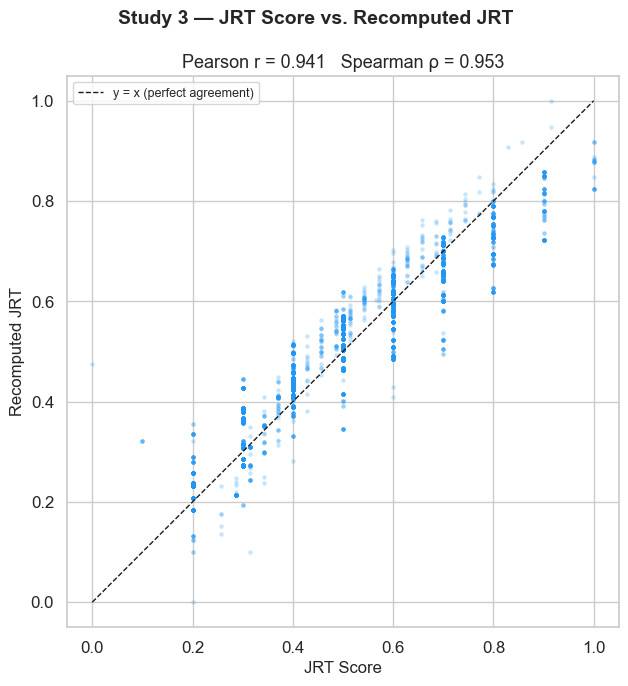

Pearson r  = 0.9410
Spearman ρ = 0.9525
n          = 6370
Saved: results/study3_jrt_vs_recomputed.png


In [22]:

# ------------------------------------------------------------------ #
# Study 3 — Sanity Check: JRT Score vs. Recomputed JRT
# ------------------------------------------------------------------ #
from style_guide import S, apply_theme, savefig
apply_theme()

has_mean3  = df3_results['RaterMEAN'].notna()
jrt_sub3   = df3_results.loc[has_mean3, 'jrt'].values
mean_sub3  = df3_results.loc[has_mean3, 'RaterMEAN'].values

# Normalize RaterMEAN to [0, 1] for same-scale comparison
mean_norm3 = (mean_sub3 - mean_sub3.min()) / (mean_sub3.max() - mean_sub3.min())

r_vm3,   _ = pearsonr(mean_norm3, jrt_sub3)
rho_vm3, _ = spearmanr(mean_norm3, jrt_sub3)

fig, ax = plt.subplots(figsize=(S.FIG_1xN_UNIT, S.FIG_1xN_UNIT))
fig.suptitle("Study 3 — JRT Score vs. Recomputed JRT",
             fontsize=S.SUPTITLE_SIZE, fontweight=S.TITLE_WEIGHT)

ax.scatter(mean_norm3, jrt_sub3,
           alpha=S.SCATTER_ALPHA_LIGHT, s=S.SCATTER_SIZE_SMALL,
           color=S.MODEL_COLORS['7b'], linewidths=0, rasterized=S.SCATTER_RASTERIZED)
ax.plot([0, 1], [0, 1], S.IDEAL_LINE, lw=S.IDEAL_LINE_LW, label="y = x (perfect agreement)")
ax.set_xlabel("JRT Score", fontsize=S.AXIS_LABEL_SIZE)
ax.set_ylabel("Recomputed JRT", fontsize=S.AXIS_LABEL_SIZE)
ax.set_title(f"Pearson r = {r_vm3:.3f}   Spearman ρ = {rho_vm3:.3f}", fontsize=S.TITLE_SIZE)
ax.legend(fontsize=S.LEGEND_SIZE_SM)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
savefig(fig, ROOT / "results" / "study3_jrt_vs_recomputed.png", hi_res=False)
plt.show()
print(f"Pearson r  = {r_vm3:.4f}")
print(f"Spearman ρ = {rho_vm3:.4f}")
print(f"n          = {has_mean3.sum()}")
print("Saved: results/study3_jrt_vs_recomputed.png")


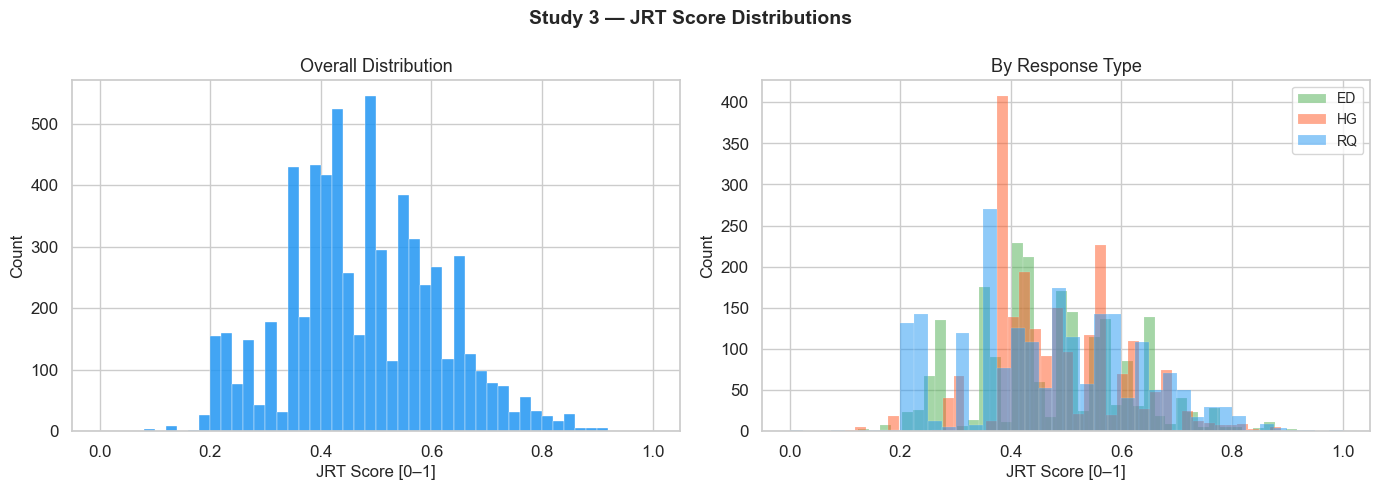

Saved: results/study3_jrt_distribution.png

Type        n     mean      std   median
------------------------------------------
ED       2106   0.4750   0.1362   0.4600
HG       2142   0.4862   0.1149   0.4631
RQ       2123   0.4720   0.1594   0.4840


In [23]:

# ------------------------------------------------------------------ #
# Study 3 — JRT Score Distributions (Overall + By Response Type)
# ------------------------------------------------------------------ #
from style_guide import S, apply_theme, savefig
apply_theme()

type_colors = {'RQ': S.MODEL_COLORS['7b'], 'HG': S.MODEL_COLORS['13b'], 'ED': '#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=S.FIG_1x2)
fig.suptitle("Study 3 — JRT Score Distributions",
             fontsize=S.SUPTITLE_SIZE, fontweight=S.TITLE_WEIGHT)

# Left: overall
axes[0].hist(jrt3, bins=50, color=S.MODEL_COLORS['7b'],
             edgecolor='white', linewidth=0.3, alpha=S.BAR_ALPHA)
axes[0].set_xlabel("JRT Score [0–1]", fontsize=S.AXIS_LABEL_SIZE)
axes[0].set_ylabel("Count", fontsize=S.AXIS_LABEL_SIZE)
axes[0].set_title("Overall Distribution", fontsize=S.TITLE_SIZE)

# Right: by response type
for rtype in sorted(df3_results['type'].unique()):
    vals = df3_results.loc[df3_results['type'] == rtype, 'jrt'].values
    axes[1].hist(vals, bins=40, alpha=0.5, label=rtype,
                 edgecolor='white', linewidth=0.2,
                 color=type_colors.get(rtype, 'gray'))
axes[1].set_xlabel("JRT Score [0–1]", fontsize=S.AXIS_LABEL_SIZE)
axes[1].set_ylabel("Count", fontsize=S.AXIS_LABEL_SIZE)
axes[1].set_title("By Response Type", fontsize=S.TITLE_SIZE)
axes[1].legend(fontsize=S.LEGEND_SIZE)

plt.tight_layout()
savefig(fig, ROOT / "results" / "study3_jrt_distribution.png", hi_res=False)
plt.show()
print("Saved: results/study3_jrt_distribution.png")

# Per-type stats
print(f"\n{'Type':<6} {'n':>6} {'mean':>8} {'std':>8} {'median':>8}")
print("-" * 42)
for rtype in sorted(df3_results['type'].unique()):
    v = df3_results.loc[df3_results['type'] == rtype, 'jrt']
    print(f"{rtype:<6} {len(v):>6d} {v.mean():>8.4f} {v.std():>8.4f} {v.median():>8.4f}")


In [24]:

# ------------------------------------------------------------------ #
# Study 3 — Export JRT Scores
# ------------------------------------------------------------------ #

# Deduplicate by exact response text
before_dedup3 = len(df3_results)
dedup3 = (
    df3_results
    .groupby('response', sort=False)
    .agg(
        ResponseID   = ('ResponseID', 'first'),
        item         = ('item',       'first'),
        type         = ('type',       'first'),
        SubjID       = ('SubjID',     'first'),
        RaterMEAN    = ('RaterMEAN',  'mean'),
        theta_eap    = ('theta_eap',  'mean'),
        theta_se     = ('theta_se',   'mean'),
        jrt          = ('jrt',        'mean'),
        n_duplicates = ('ResponseID', 'count'),
    )
    .reset_index()
)
after_dedup3 = len(dedup3)
print(f"Before dedup : {before_dedup3}")
print(f"After dedup  : {after_dedup3}  ({before_dedup3 - after_dedup3} duplicates removed)")

out3       = ROOT / "results" / "study3_jrt_recomputed.csv"
dedup_out3 = ROOT / "results" / "study3_jrt_recomputed_dedup.csv"

df3_results[['ResponseID', 'SubjID', 'item', 'type', 'response',
             'RaterMEAN', 'theta_eap', 'theta_se', 'jrt']].to_csv(out3, index=False)
dedup3.to_csv(dedup_out3, index=False)

print(f"\nSaved: {out3}")
print(f"Saved: {dedup_out3}")


Before dedup : 6371
After dedup  : 6205  (166 duplicates removed)

Saved: C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\results\study3_jrt_recomputed.csv
Saved: C:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\results\study3_jrt_recomputed_dedup.csv


## Inter-Rater Agreement by JRT Label Bucket

Responses are binned by their **normalized JRT score** (`jrt_recomputed`, [0–1]) into 10 equal-width buckets of 0.1.

Each bar shows the proportion of responses in each agreement tier, based on the **range** of raw rater scores (1–5):

| Tier | Range | Meaning |
|---|---|---|
| Full agreement | 0 | All raters gave identical scores |
| Near agreement | 1 | Scores span at most 1 point |
| Moderate disagreement | 2 | Scores span 2 points |
| High disagreement | ≥ 3 | Scores span 3 or more points |

This reveals whether rater consensus is higher for clearly low- or high-creativity responses and breaks down at the middle of the scale.

 bucket   n  Full (range=0)  Near (range=1)  Moderate (range=2)  High (range≥3)
0.0–0.1  32            18.8            71.9                 6.2             3.1
0.1–0.2  10             0.0             0.0                90.0            10.0
0.2–0.3  22             0.0           100.0                 0.0             0.0
0.3–0.4 366            45.1            48.6                 5.2             1.1
0.4–0.5  96             9.4            51.0                35.4             4.2
0.5–0.6 289            24.6            55.7                17.6             2.1
0.6–0.7  59             1.7            66.1                23.7             8.5
0.7–0.8 133            18.8            38.3                35.3             7.5
0.8–0.9  31             3.2             0.0                51.6            45.2
0.9–1.0  24            12.5            70.8                16.7             0.0


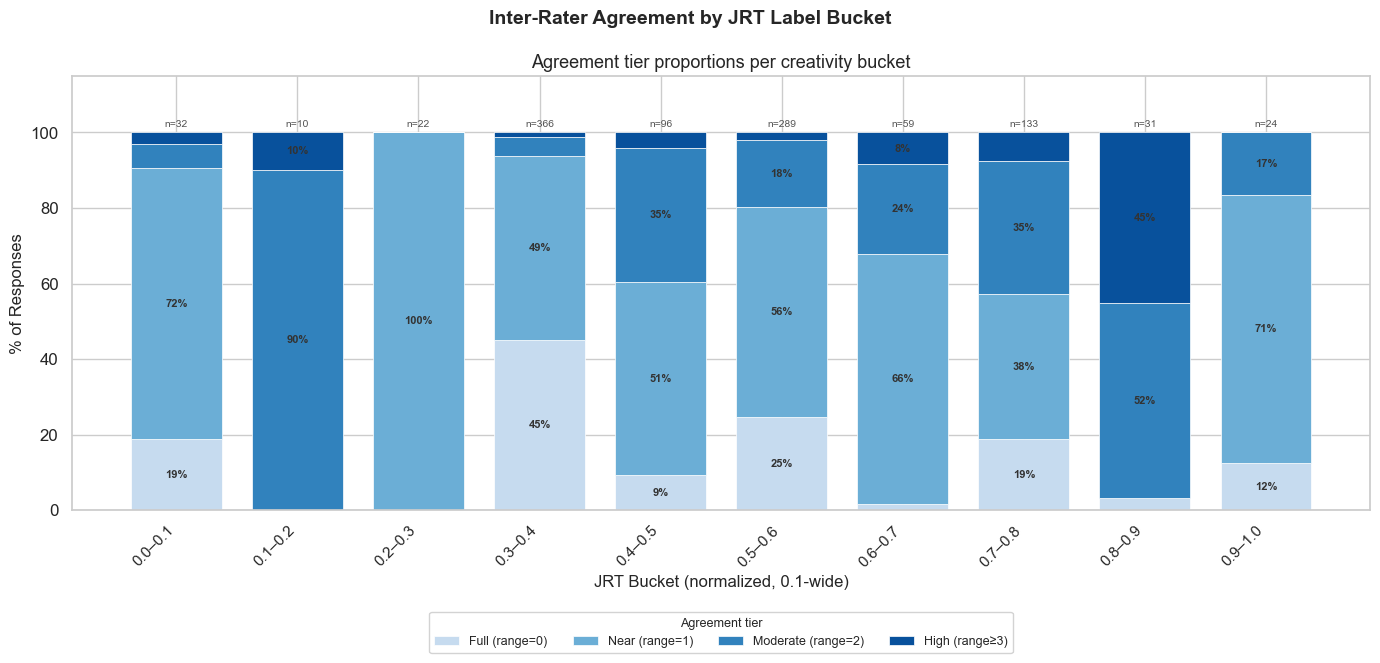

Saved: results/jrt_agreement_tiers_by_bucket.png


In [ ]:
# ------------------------------------------------------------------ #
# Inter-Rater Agreement by JRT Label Bucket  (item-gen dataset)
# ------------------------------------------------------------------ #
from style_guide import S, apply_theme, savefig
apply_theme()

# ── Per-response range of raw rater scores (1-5 scale, missing ignored) ───────
rater_raw = df_results[RATER_COLS].apply(pd.to_numeric, errors='coerce')
df_results['rater_range'] = rater_raw.max(axis=1) - rater_raw.min(axis=1)

# ── Bin by normalized JRT ─────────────────────────────────────────────────────
bin_edges  = np.arange(0, 1.01, 0.1)
bin_labels = [f"{lo:.1f}–{hi:.1f}" for lo, hi in zip(bin_edges[:-1], bin_edges[1:])]

df_results['jrt_bucket'] = pd.cut(
    df_results['jrt_recomputed'], bins=bin_edges,
    labels=bin_labels, include_lowest=True
)

# ── Agreement tiers ───────────────────────────────────────────────────────────
tiers = {
    'Full (range=0)':       lambda r: r == 0,
    'Near (range=1)':       lambda r: r == 1,
    'Moderate (range=2)':   lambda r: r == 2,
    'High (range≥3)':       lambda r: r >= 3,
}
# Sequential blue (ColorBrewer Blues): light = full agreement → dark = high disagreement
tol_colors = ['#c6dbef', '#6baed6', '#3182bd', '#08519c', '#022a5a']
tier_colors = tol_colors  # zip with 4 tiers uses first 4

# ── Compute proportions per bucket ───────────────────────────────────────────
rows = []
for bucket, grp in df_results.groupby('jrt_bucket', observed=True):
    n = len(grp)
    row = {'bucket': bucket, 'n': n}
    for tier, fn in tiers.items():
        row[tier] = fn(grp['rater_range']).mean() * 100
    rows.append(row)

agree_df = pd.DataFrame(rows)

print(agree_df.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

# ── Stacked bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(S.FIG_1xN_UNIT * 2, S.FIG_1xN_UNIT))
fig.suptitle("Inter-Rater Agreement by JRT Label Bucket",
             fontsize=S.SUPTITLE_SIZE, fontweight=S.TITLE_WEIGHT)

x      = np.arange(len(agree_df))
bottom = np.zeros(len(agree_df))

for (tier, _), color in zip(tiers.items(), tier_colors):
    vals = agree_df[tier].values
    ax.bar(x, vals, bottom=bottom, color=color, edgecolor='white',
           linewidth=0.5, width=0.75, label=tier)
    # Label segments ≥ 8% to avoid clutter
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 8:
            # White text on darker segments, dark text on lighter segments
            txt_color = 'white' if color in ('#3182bd', '#08519c', '#022a5a') else '#333333'
            ax.text(xi, b + v / 2, f"{v:.0f}%",
                    ha='center', va='center', fontsize=8,
                    color=txt_color, fontweight='bold')
    bottom += vals

# n labels above each bar
for xi, row in enumerate(agree_df.itertuples()):
    ax.text(xi, 101, f"n={row.n}", ha='center', va='bottom',
            fontsize=7.5, color='#555555')

ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=S.TICK_LABEL_SIZE)
ax.set_xlabel("JRT Bucket (normalized, 0.1-wide)", fontsize=S.AXIS_LABEL_SIZE)
ax.set_ylabel("% of Responses", fontsize=S.AXIS_LABEL_SIZE)
ax.set_ylim(0, 115)
ax.set_title("Agreement tier proportions per creativity bucket", fontsize=S.TITLE_SIZE)
ax.legend(title="Agreement tier", fontsize=S.LEGEND_SIZE_SM, title_fontsize=S.LEGEND_SIZE_SM,
          loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=4, framealpha=0.85)

plt.tight_layout()
savefig(fig, ROOT / "results" / "jrt_agreement_tiers_by_bucket.png", hi_res=False)
plt.show()
print("Saved: results/jrt_agreement_tiers_by_bucket.png")